Total Neo4j facts: 48


,text,source,embedding_model
0,Tarunya Pitika (Acne vulgaris) manifests as None.,neo4j,all-MiniLM-L6-v2
1,Tarunya Pitika (Acne vulgaris) manifests as None.,neo4j,all-MiniLM-L6-v2
2,Tarunya Pitika (Acne vulgaris) manifests as None.,neo4j,all-MiniLM-L6-v2
3,Tarunya Pitika (Acne vulgaris) manifests as None.,neo4j,all-MiniLM-L6-v2
4,Vicharchika (Eczema) manifests as None.,neo4j,all-MiniLM-L6-v2


FAISS vectors: 48


,query,model,Precision@K,Recall@K,MRR,nDCG@K
0,Joint pain and stiffness symptoms,Neo4j-FAISS (ST),1.0,1.250000,1.0,1.151020
1,Diseases that cause knee pain,Neo4j-FAISS (ST),1.0,2.500000,1.0,1.807839
2,Treatments for Sandhigata Vata,Neo4j-FAISS (ST),1.0,1.666667,1.0,1.383649
3,Herbs beneficial for joint disorders,Neo4j-FAISS (ST),0.0,0.000000,0.0,0.000000
4,Causes of joint-related diseases,Neo4j-FAISS (ST),0.2,0.333333,1.0,0.469279
5,Vata imbalance causing joint pain,Neo4j-FAISS (ST),1.0,1.666667,1.0,1.383649


,Neo4j-FAISS Score
Precision@K,0.700000
Recall@K,1.236111
MRR,0.833333
nDCG@K,1.032573


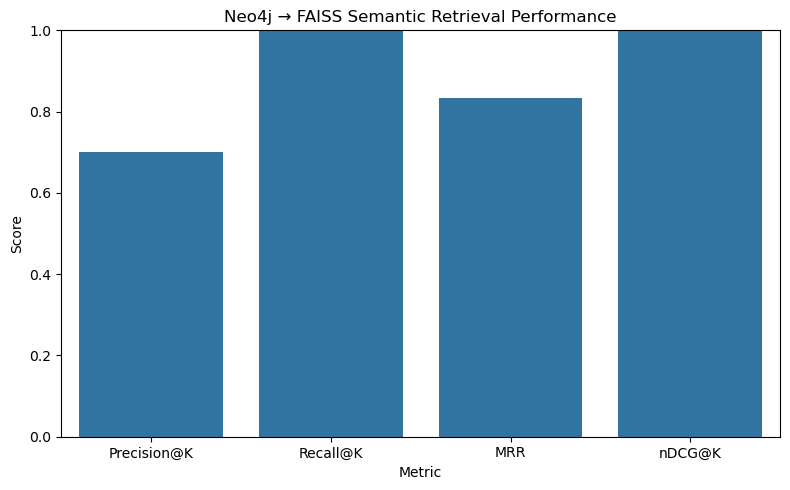

In [3]:
# -------------------------------------------------------
# 04_neo4j_evaluation.ipynb
# Evaluation of Neo4j → FAISS Semantic Retrieval
# -------------------------------------------------------

import numpy as np
import pandas as pd
import faiss
from pathlib import Path
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------
# Paths
# -------------------------------------------------------
BASE_DIR = Path("graph")
EMB_DIR = BASE_DIR / "embeddings"
INDEX_DIR = BASE_DIR / "indices"

TOP_K = 5
MODEL_NAME = "all-MiniLM-L6-v2"

# -------------------------------------------------------
# Load metadata (Neo4j-derived facts)
# -------------------------------------------------------
meta_df = pd.read_parquet(EMB_DIR / "metadata.parquet")

print("Total Neo4j facts:", len(meta_df))
display(meta_df.head())


# -------------------------------------------------------
# Load FAISS index
# -------------------------------------------------------
index = faiss.read_index(str(INDEX_DIR / "faiss_index_st.index"))
print("FAISS vectors:", index.ntotal)


# -------------------------------------------------------
# Load SentenceTransformer
# -------------------------------------------------------
model = SentenceTransformer(MODEL_NAME)


# -------------------------------------------------------
# Semantic search
# -------------------------------------------------------
def semantic_search(query, top_k=5):
    qv = model.encode([query], convert_to_numpy=True).astype("float32")
    _, indices = index.search(qv, top_k)
    return meta_df.iloc[indices[0]]["text"].tolist()

# -------------------------------------------------------
# Evaluation queries + ground truth
# -------------------------------------------------------
evaluation_queries = [

    {
        "query": "Joint pain and stiffness symptoms",
        "relevant_terms": ["joint", "pain", "stiffness", "sandhigata"]
    },

    {
        "query": "Diseases that cause knee pain",
        "relevant_terms": ["knee", "pain"]
    },

    {
        "query": "Treatments for Sandhigata Vata",
        "relevant_terms": ["treated", "treatment", "sandhigata"]
    },

    {
        "query": "Herbs beneficial for joint disorders",
        "relevant_terms": ["herb", "beneficial", "joint"]
    },

    {
        "query": "Causes of joint-related diseases",
        "relevant_terms": ["caused", "nidana", "cause"]
    },

    {
        "query": "Vata imbalance causing joint pain",
        "relevant_terms": ["vata", "joint", "pain"]
    }
]

# -------------------------------------------------------
# Relevance check
# -------------------------------------------------------
def is_relevant(text, relevant_terms):
    text = text.lower()
    return any(term in text for term in relevant_terms)



# -------------------------------------------------------
# Evaluation metrics
# -------------------------------------------------------
def precision_at_k(retrieved, relevant_terms, k):
    rel_count = sum(is_relevant(t, relevant_terms) for t in retrieved[:k])
    return rel_count / k


def recall_at_k(retrieved, relevant_terms):
    rel_count = sum(is_relevant(t, relevant_terms) for t in retrieved)
    return rel_count / len(relevant_terms)


def mean_reciprocal_rank(retrieved, relevant_terms):
    for i, text in enumerate(retrieved):
        if is_relevant(text, relevant_terms):
            return 1 / (i + 1)
    return 0.0


def dcg_at_k(retrieved, relevant_terms, k):
    score = 0.0
    for i, text in enumerate(retrieved[:k]):
        if is_relevant(text, relevant_terms):
            score += 1 / np.log2(i + 2)
    return score


def ndcg_at_k(retrieved, relevant_terms, k):
    dcg = dcg_at_k(retrieved, relevant_terms, k)
    ideal_dcg = sum(1 / np.log2(i + 2) for i in range(min(len(relevant_terms), k)))
    return dcg / ideal_dcg if ideal_dcg > 0 else 0.0


# -------------------------------------------------------
# Run evaluation
# -------------------------------------------------------
results = []

for item in evaluation_queries:
    query = item["query"]
    relevant_terms = item["relevant_terms"]

    retrieved = semantic_search(query, TOP_K)

    results.append({
        "query": query,
        "model": "Neo4j-FAISS (ST)",
        "Precision@K": precision_at_k(retrieved, relevant_terms, TOP_K),
        "Recall@K": recall_at_k(retrieved, relevant_terms),
        "MRR": mean_reciprocal_rank(retrieved, relevant_terms),
        "nDCG@K": ndcg_at_k(retrieved, relevant_terms, TOP_K),
    })

df_results = pd.DataFrame(results)
display(df_results)

# -------------------------------------------------------
# Summary
# -------------------------------------------------------
summary = df_results[["Precision@K", "Recall@K", "MRR", "nDCG@K"]].mean()
display(summary.to_frame(name="Neo4j-FAISS Score"))


# -------------------------------------------------------
# Visualization
# -------------------------------------------------------
plot_df = summary.reset_index()
plot_df.columns = ["Metric", "Score"]

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x="Metric", y="Score")
plt.title("Neo4j → FAISS Semantic Retrieval Performance")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
